<a href="https://colab.research.google.com/github/Nick-Prism/sleep-lifestyle-analysis/blob/main/DEV_AAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("minahilfatima12328/lifestyle-and-sleep-patterns")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lifestyle-and-sleep-patterns' dataset.
Path to dataset files: /kaggle/input/lifestyle-and-sleep-patterns


In [ ]:
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
#file=files.upload()

In [ ]:
data=pd.read_csv("/kaggle/input/lifestyle-and-sleep-patterns/Sleep_health_and_lifestyle_dataset.csv")

In [ ]:
data.shape

(374, 13)

In [ ]:
data.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [ ]:

for i in ["Occupation","BMI Category","Sleep Disorder"]:
  print(i,data[i].unique(),"\n")


Occupation ['Software Engineer' 'Doctor' 'Sales Representative' 'Teacher' 'Nurse'
 'Engineer' 'Accountant' 'Scientist' 'Lawyer' 'Salesperson' 'Manager'] 

BMI Category ['Overweight' 'Normal' 'Obese' 'Normal Weight'] 

Sleep Disorder [nan 'Sleep Apnea' 'Insomnia'] 



In [ ]:
datadescription=data.describe()
datadescription.drop('Person ID',axis=1,inplace=True)
datadescription

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [ ]:
data.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Blood Pressure,0


In [ ]:
data['Sleep Disorder'].fillna('no sleep disorder', inplace=True)


/tmp/ipython-input-2651502585.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Sleep Disorder'].fillna('no sleep disorder', inplace=True)


In [ ]:
data["Sleep Disorder"].unique()

array(['no sleep disorder', 'Sleep Apnea', 'Insomnia'], dtype=object)

In [ ]:
df = pd.DataFrame(data)
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,no sleep disorder
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,no sleep disorder
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,no sleep disorder
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [ ]:
df.tail()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [ ]:
df.columns = ["person_id","gender","age","occupation","sleep_duration","quality_of_sleep","physical_activity_level","stress_level","bmi_category",
              "blood_pressure","heart_rate","daily_steps","sleep_disorder"]

In [ ]:
def bar_plot(variable):

    var_data = df[variable]
    var_counts = var_data.value_counts()

    plt.figure(figsize=(12,6))
    bars = plt.bar(var_counts.index,var_counts,color="skyblue",edgecolor="black")
    plt.bar_label(container=bars,labels=var_counts,label_type="edge")
    plt.ylabel("Frequency")
    plt.title(f"Distrubution of {variable}")
    if variable == "blood_pressure" or variable == "occupation":
        plt.xticks(rotation=90)
    plt.show()

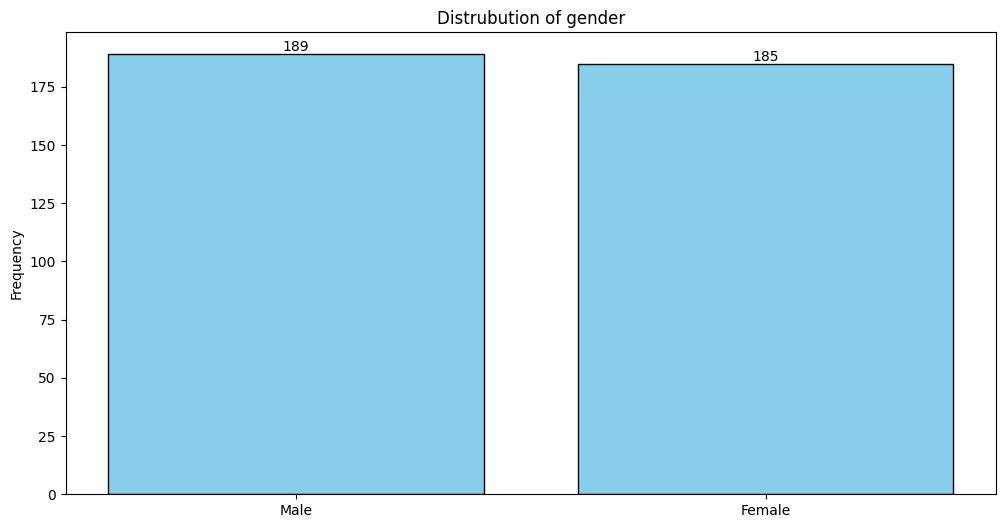

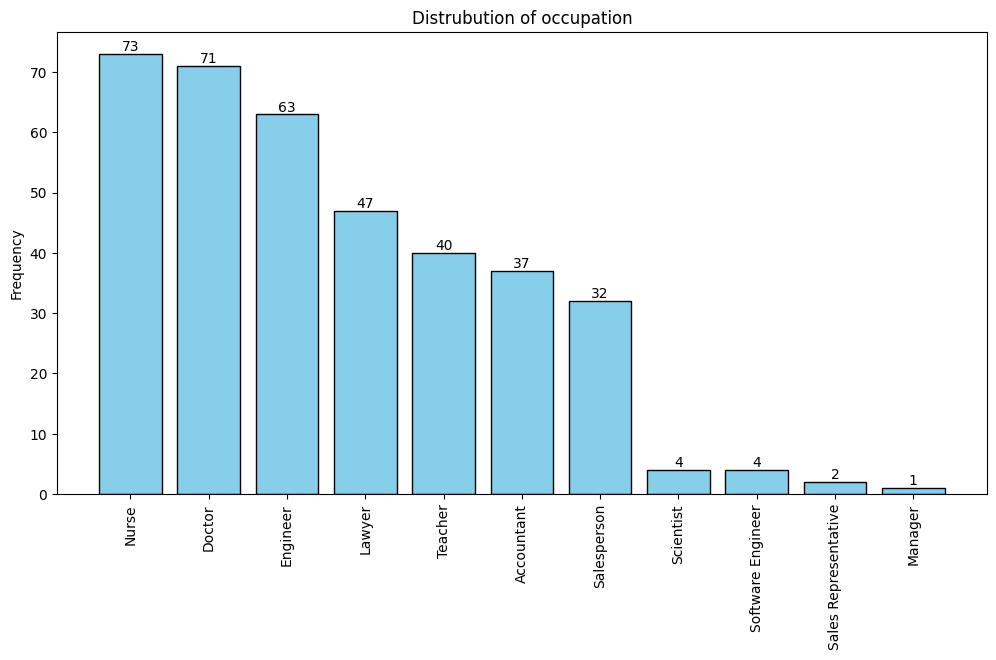

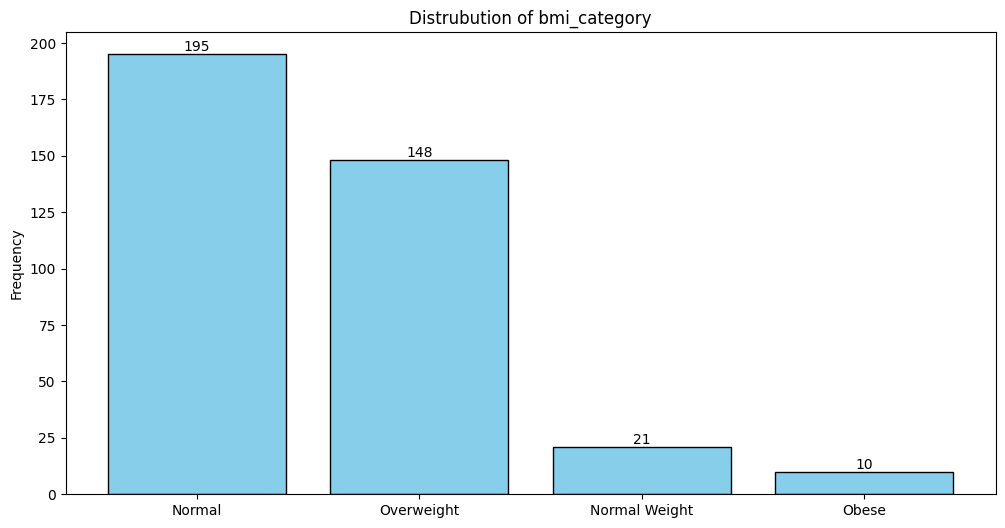

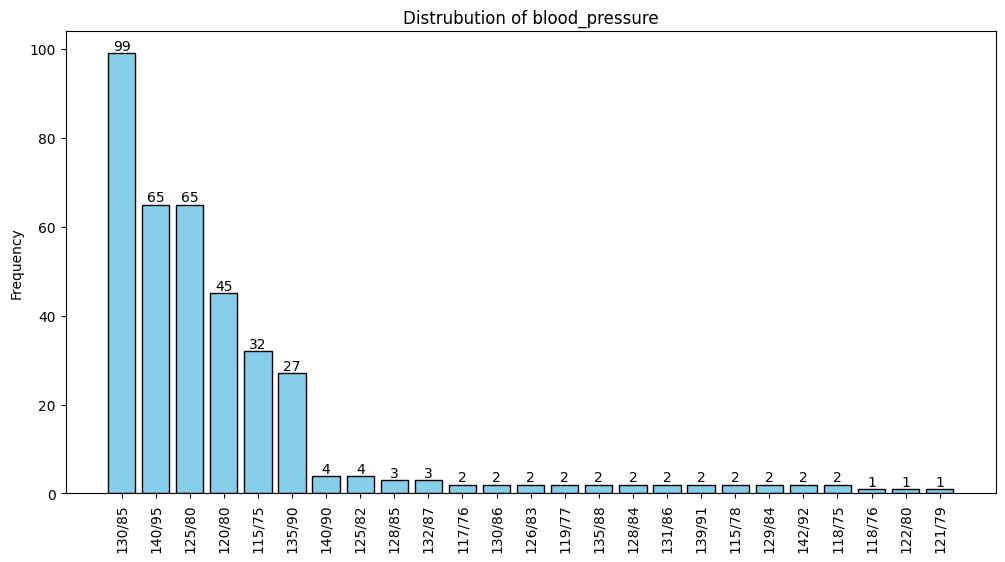

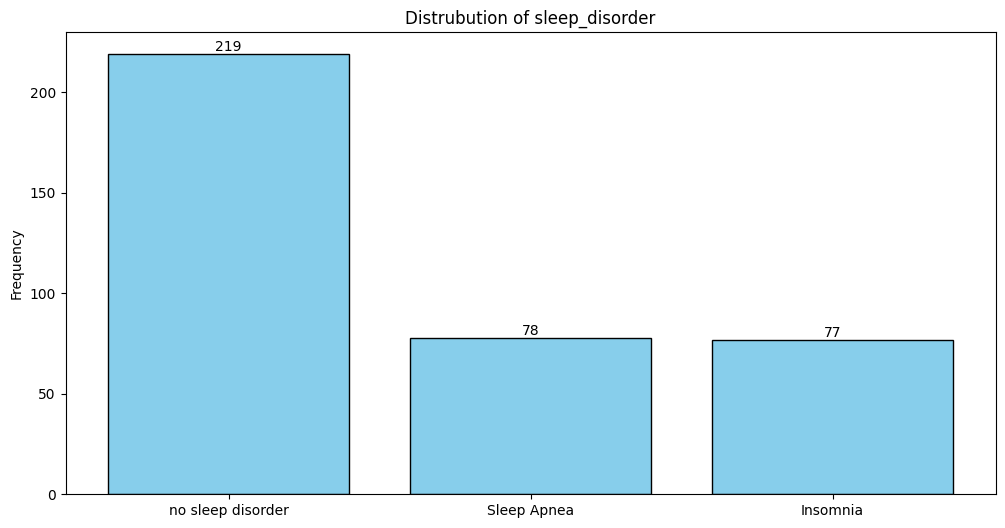

In [ ]:
categorical_vars = ["gender","occupation","bmi_category","blood_pressure","sleep_disorder"]

for c in categorical_vars:
    bar_plot(c)

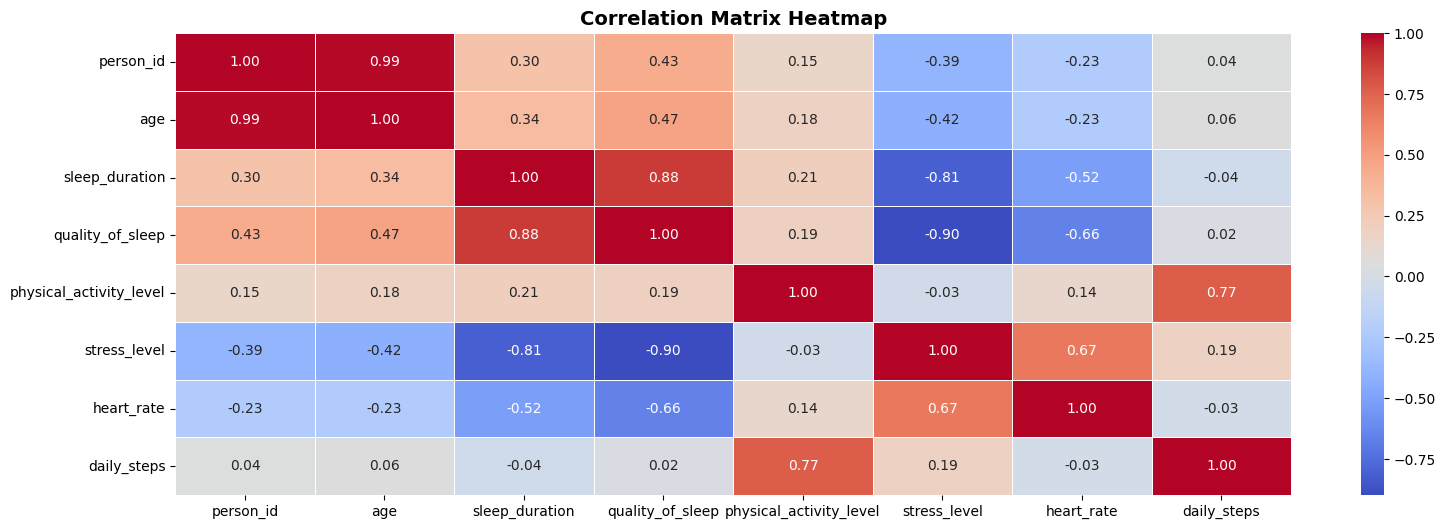

In [ ]:
# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(18,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap", fontsize=14, fontweight='bold')
plt.show()

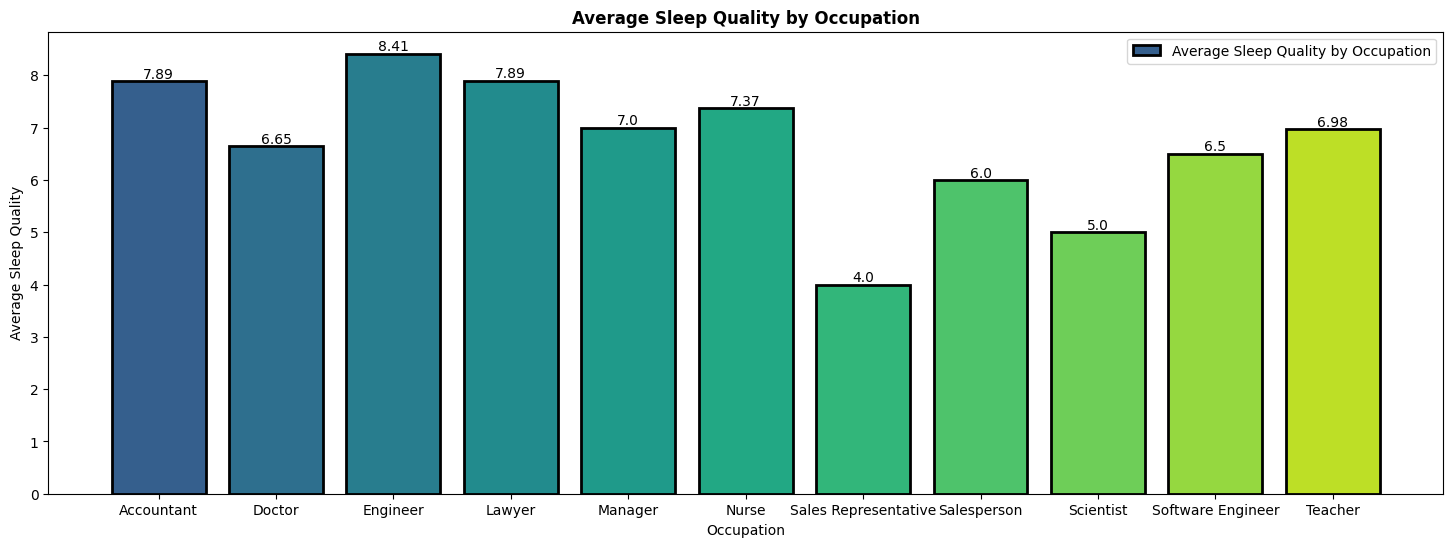

In [ ]:
# Compute mean sleep quality by occupation
occupation_sleep_mean = df.groupby("occupation")[["quality_of_sleep"]].mean()

# Generate a color gradient
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(occupation_sleep_mean.index)))
plt.figure(figsize=(18,6))
# Plot bar chart
bars = plt.bar(
    occupation_sleep_mean.index,
    occupation_sleep_mean["quality_of_sleep"],
    color=colors,
    edgecolor="black",
    linewidth=2,
    label="Average Sleep Quality by Occupation"
)

# Add labels on bars
plt.bar_label(bars, labels=np.round(occupation_sleep_mean["quality_of_sleep"], 2), label_type="edge")

# Title and legend
plt.title("Average Sleep Quality by Occupation", fontweight='bold')
plt.ylabel("Average Sleep Quality")
plt.xlabel("Occupation")
plt.legend()
plt.show()

# Clean up
del occupation_sleep_mean

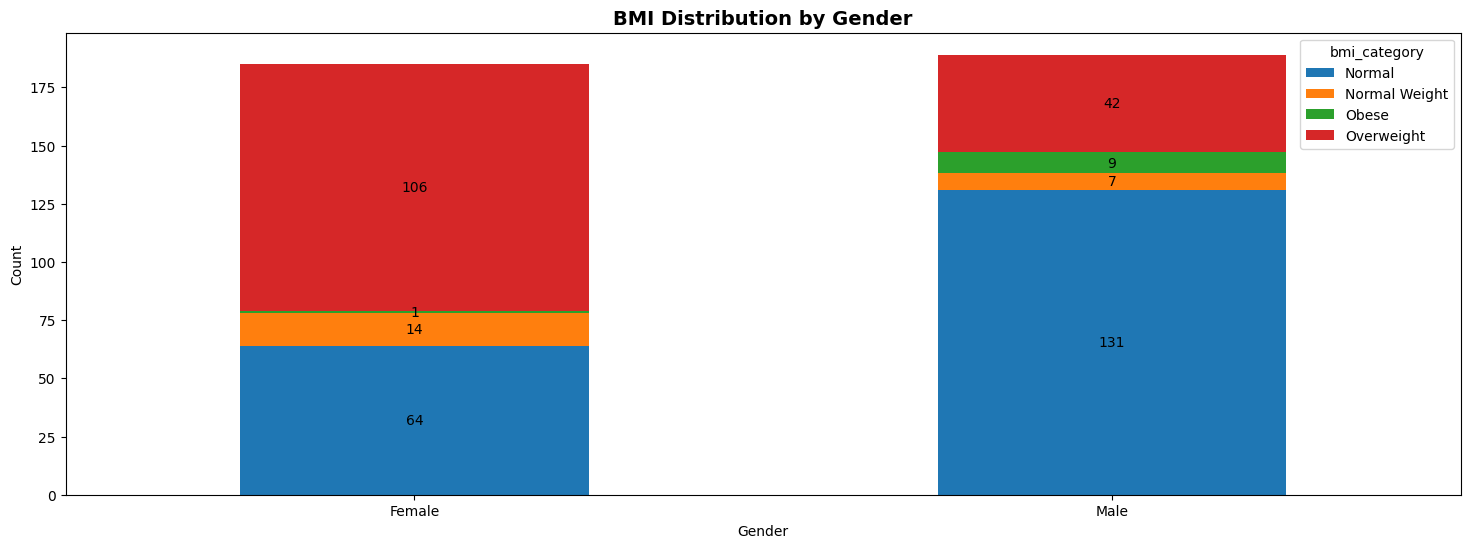

In [ ]:
# Group by gender and BMI category
df_grouped = df.groupby(["gender", "bmi_category"]).size().reset_index(name='count')

# Pivot table for stacked bar plot
df_pivot = df_grouped.pivot(index='gender', columns='bmi_category', values='count')

# Plot stacked bar chart
ax = df_pivot.plot(kind='bar', stacked=True, figsize=(18,6))
plt.title("BMI Distribution by Gender", fontsize=14, fontweight='bold')
plt.ylabel("Count")
plt.xlabel("Gender")
plt.xticks(rotation=0)

# Add labels to each segment dynamically
for container in ax.containers:
    ax.bar_label(container, label_type='center')  # segmentin ortasına sayı yaz

plt.show()

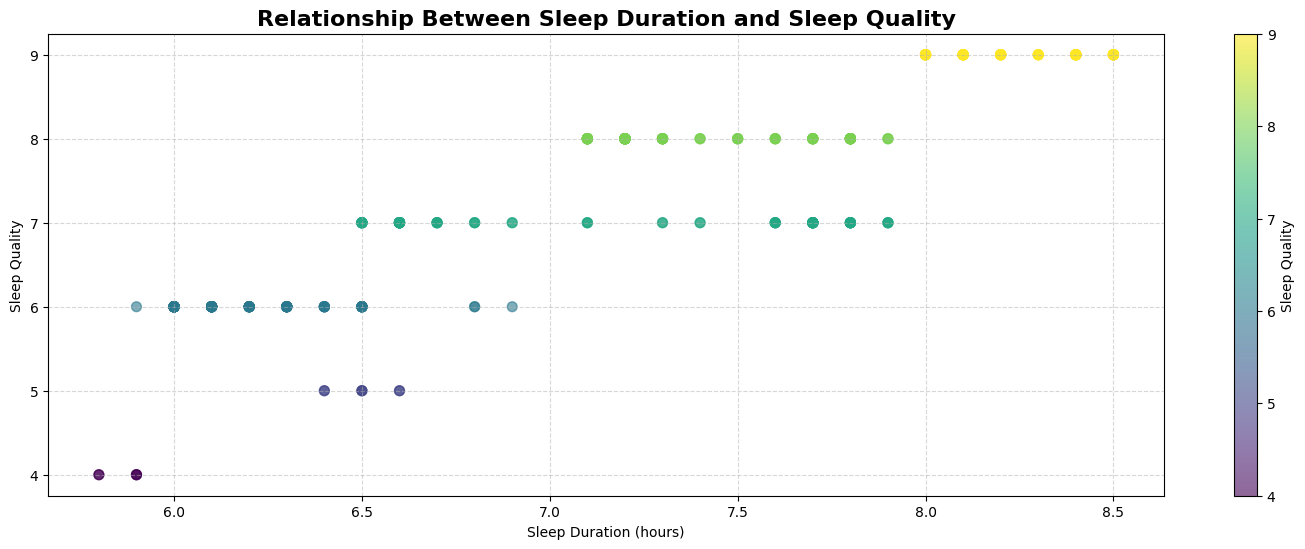

In [ ]:
# Sleep Duration vs Sleep Quality
plt.figure(figsize=(18,6))

# Scatter plot of sleep duration vs sleep quality
plt.scatter(
    df["sleep_duration"],
    df["quality_of_sleep"],
    alpha=0.6,
    c=df["quality_of_sleep"],
    cmap="viridis",
    s=50
)

plt.colorbar(label="Sleep Quality")
plt.xlabel("Sleep Duration (hours)")
plt.ylabel("Sleep Quality")
plt.title("Relationship Between Sleep Duration and Sleep Quality", fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

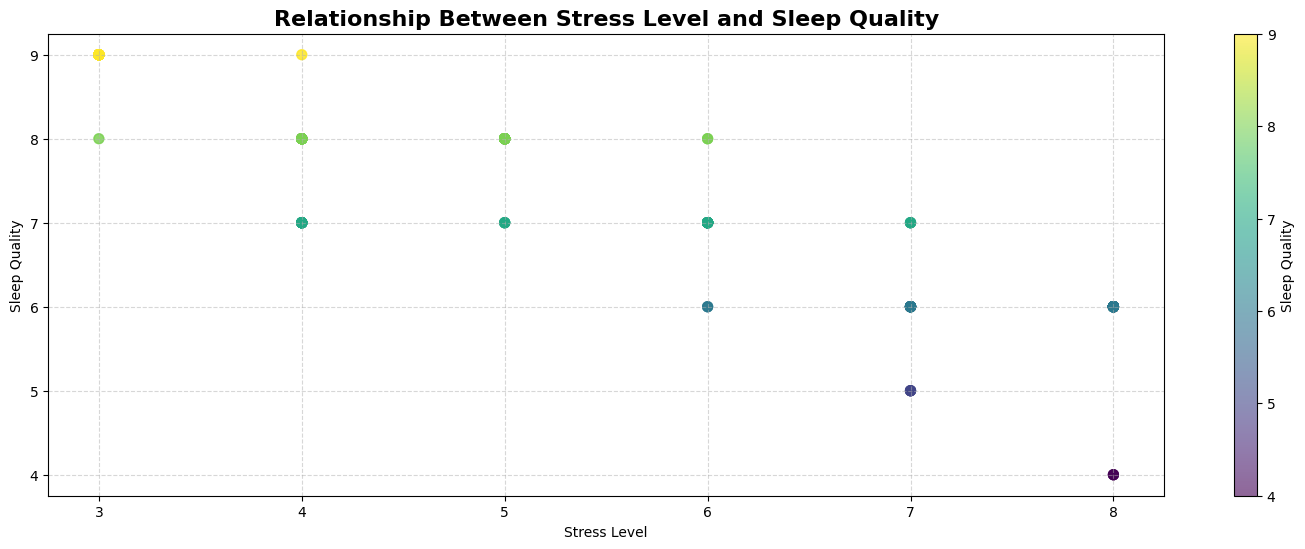

In [ ]:
plt.figure(figsize=(18,6))

# Scatter plot of stress level vs sleep quality
plt.scatter(
    df["stress_level"],
    df["quality_of_sleep"],
    alpha=0.6,
    c=df["quality_of_sleep"],
    cmap="viridis",
    s=50
)

plt.colorbar(label="Sleep Quality")
plt.xlabel("Stress Level")
plt.ylabel("Sleep Quality")
plt.title("Relationship Between Stress Level and Sleep Quality", fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

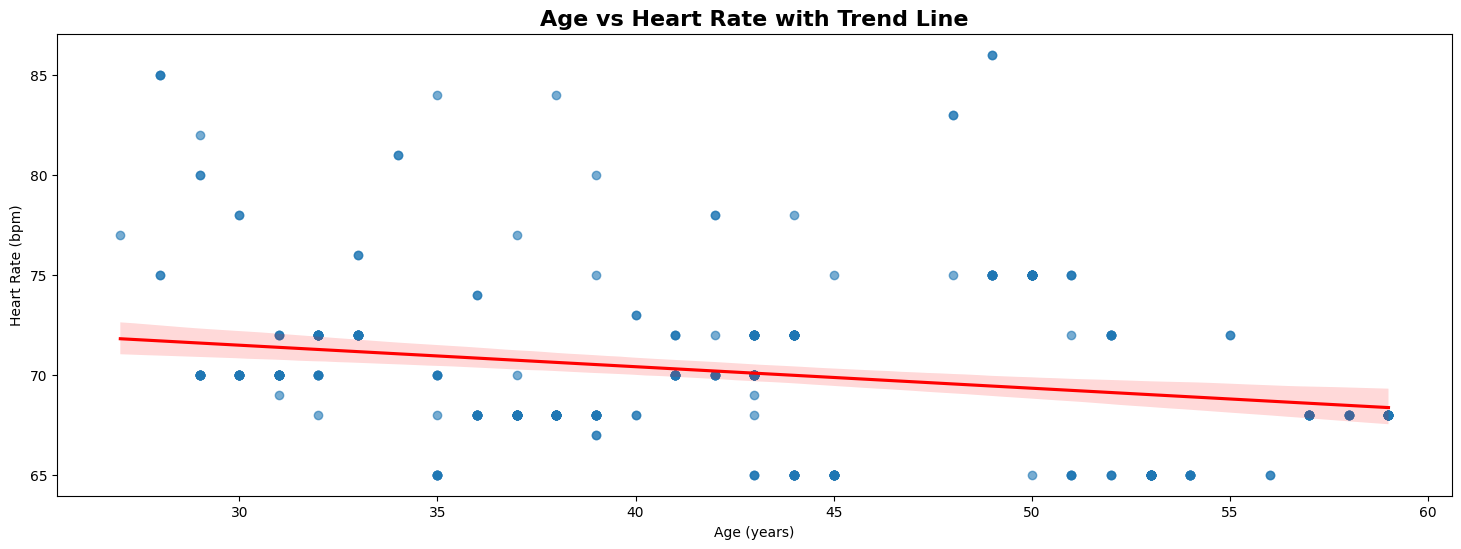

In [ ]:
plt.figure(figsize=(18,6))

# Scatter plot with regression line of age vs heart rate
sns.regplot(
    x="age",
    y="heart_rate",
    data=df,
    scatter_kws={"alpha":0.6},
    line_kws={"color":"red"}
)

plt.title("Age vs Heart Rate with Trend Line", fontsize=16, fontweight='bold')
plt.xlabel("Age (years)")
plt.ylabel("Heart Rate (bpm)")
plt.show()

/tmp/ipython-input-2649246727.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


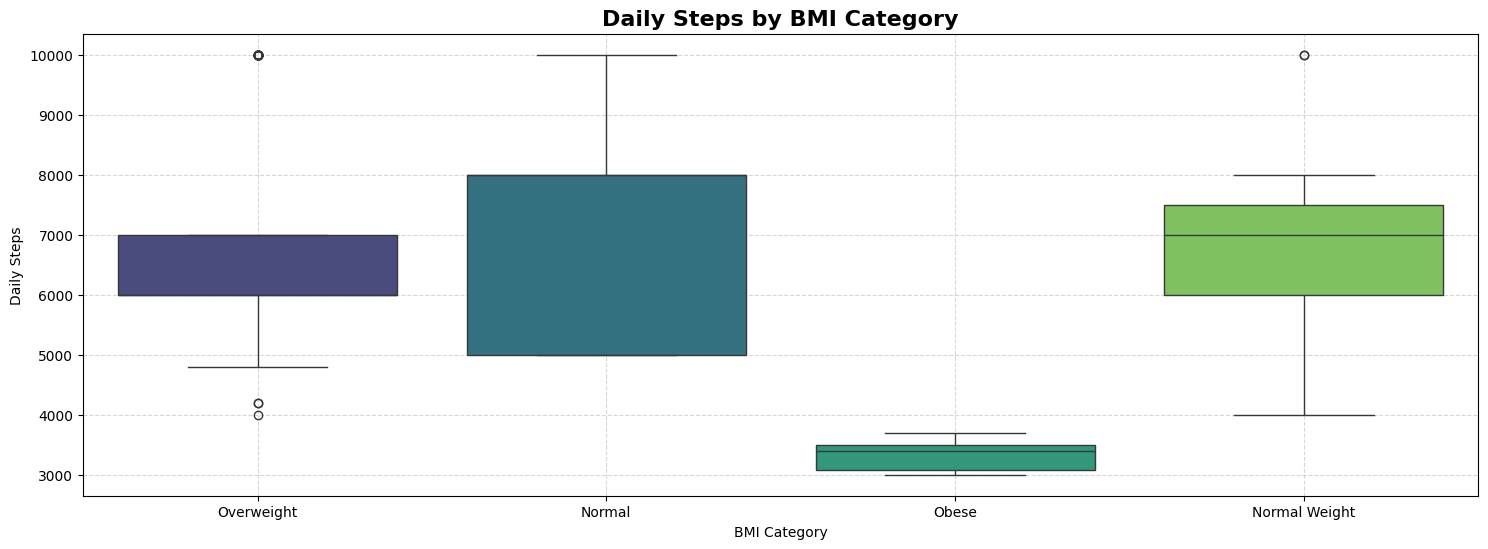

In [ ]:
plt.figure(figsize=(18,6))

# Boxplot of daily steps by BMI category
sns.boxplot(
    x="bmi_category",
    y="daily_steps",
    data=df,
    palette="viridis"
)

plt.title("Daily Steps by BMI Category", fontsize=16, fontweight="bold")
plt.xlabel("BMI Category")
plt.ylabel("Daily Steps")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

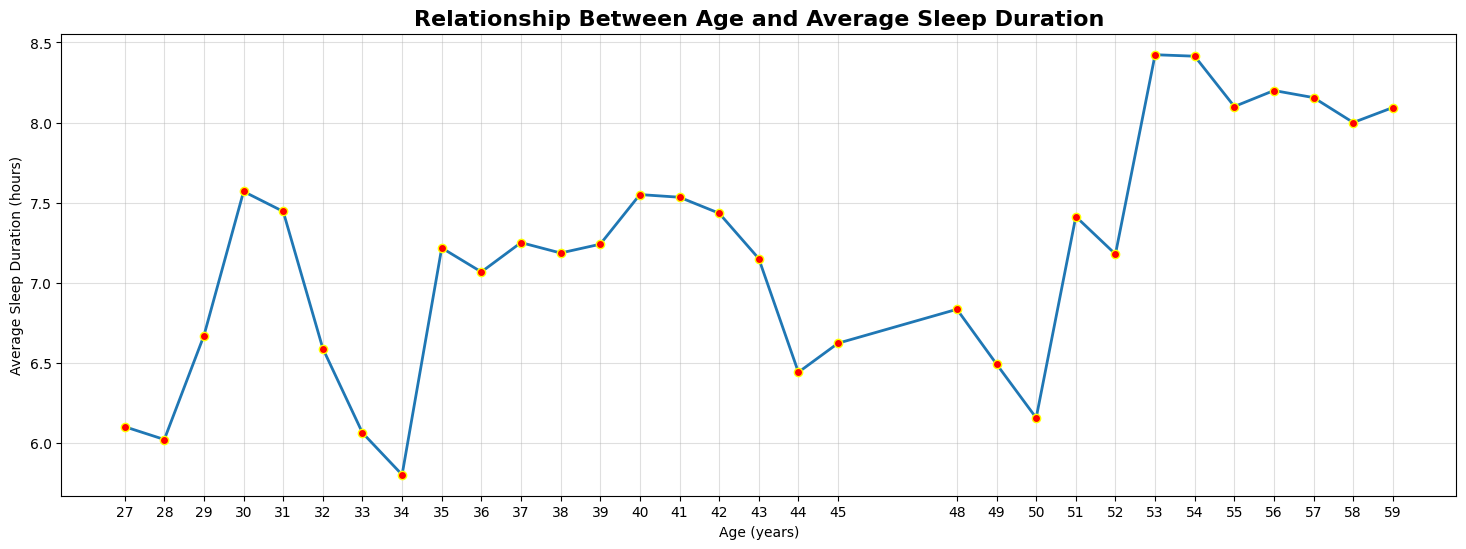

In [ ]:
# Compute average sleep duration by age
age_sleep_mean = df.groupby("age")[["sleep_duration"]].mean()

plt.figure(figsize=(18,6))

# Line plot with markers
plt.plot(
    age_sleep_mean.index,
    age_sleep_mean["sleep_duration"],
    marker="o",
    markerfacecolor="red",
    markeredgecolor="yellow",
    linewidth=2
)

plt.xlabel("Age (years)")
plt.ylabel("Average Sleep Duration (hours)")
plt.title("Relationship Between Age and Average Sleep Duration", fontsize=16, fontweight='bold')
plt.xticks(age_sleep_mean.index)
plt.grid(True, alpha=0.4)
plt.show()

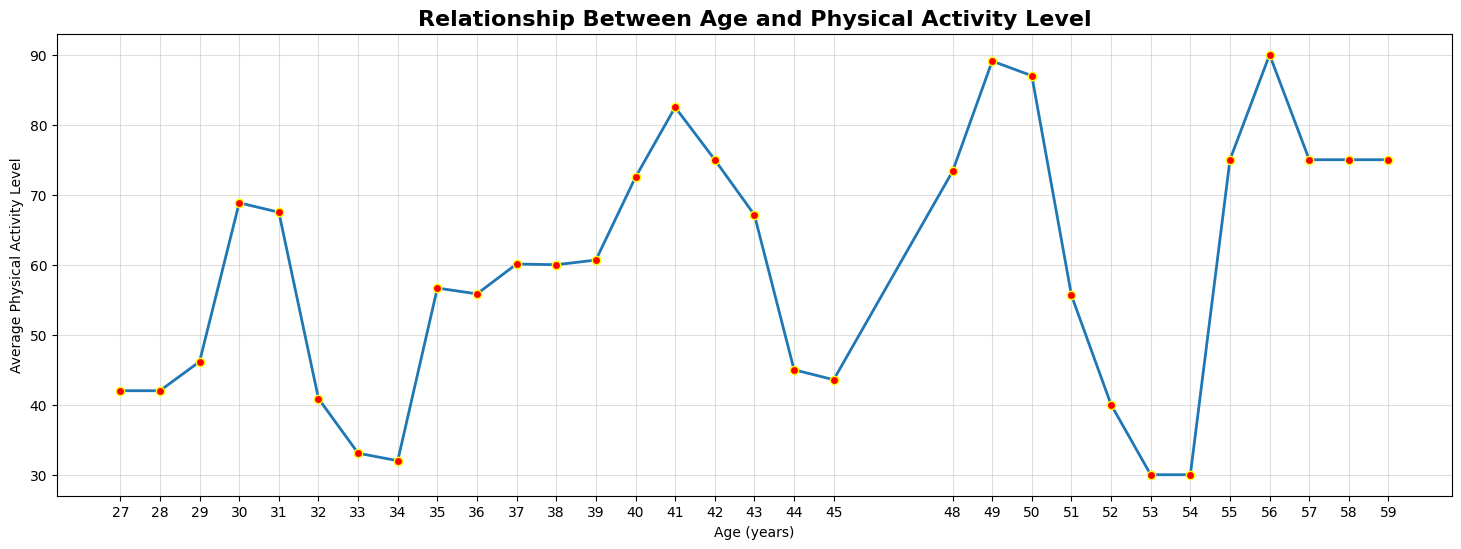

In [ ]:
# Compute average physical activity level by age
age_activity_mean = df.groupby("age")[["physical_activity_level"]].mean()

plt.figure(figsize=(18,6))

# Line plot with markers
plt.plot(
    age_activity_mean.index,
    age_activity_mean["physical_activity_level"],
    marker="o",
    markerfacecolor="red",
    markeredgecolor="yellow",
    linewidth=2
)

plt.xlabel("Age (years)")
plt.ylabel("Average Physical Activity Level")
plt.title("Relationship Between Age and Physical Activity Level", fontsize=16, fontweight='bold')
plt.xticks(age_activity_mean.index)
plt.grid(True, alpha=0.4)
plt.show()

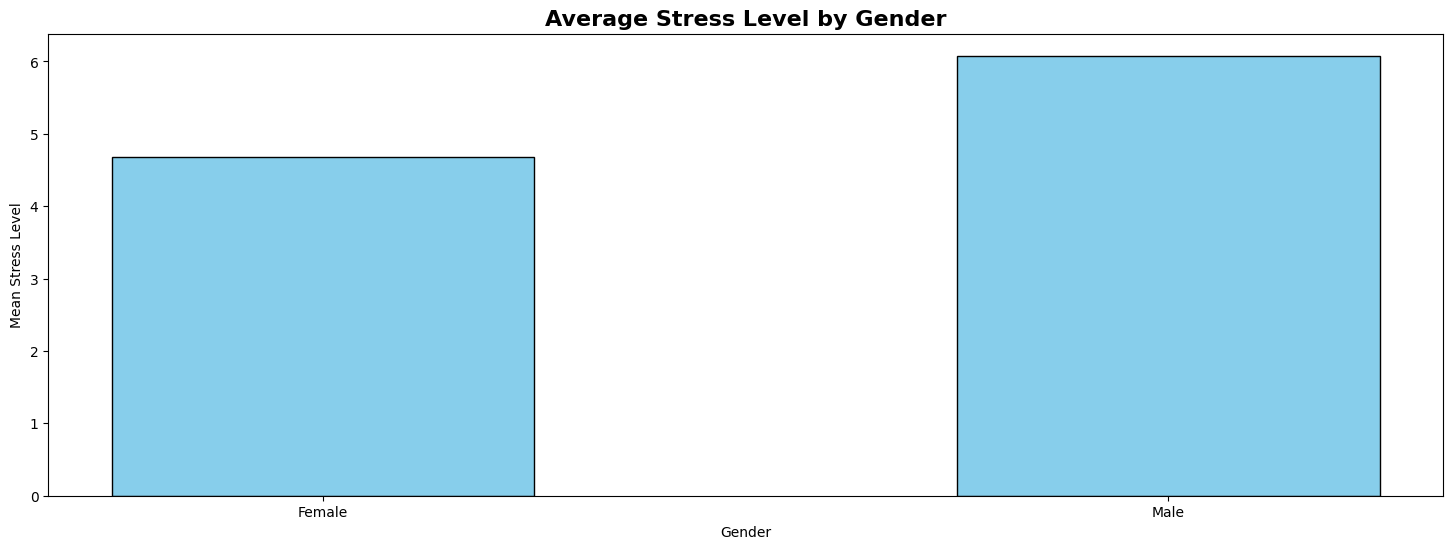

In [ ]:
# Compute average stress level by gender
gender_stress_mean = df.groupby("gender")[["stress_level"]].mean()

plt.figure(figsize=(18,6))

# Bar plot
plt.bar(
    gender_stress_mean.index,
    gender_stress_mean["stress_level"],
    width=0.5,
    color="skyblue",
    edgecolor="black"
)

# Title and labels
plt.title("Average Stress Level by Gender", fontsize=16, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Mean Stress Level")
plt.show()

# Clean up
del gender_stress_mean


/tmp/ipython-input-2789756838.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var_counts.index, y=var_counts.values, palette='viridis')


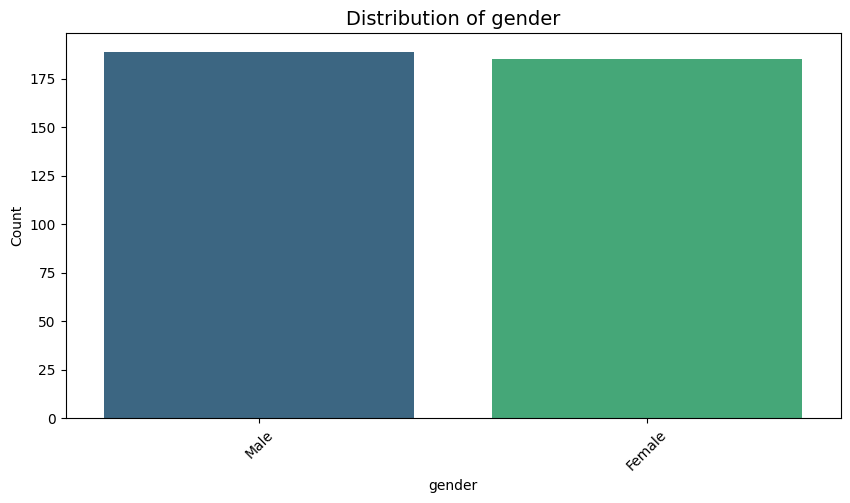

/tmp/ipython-input-2789756838.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var_counts.index, y=var_counts.values, palette='viridis')


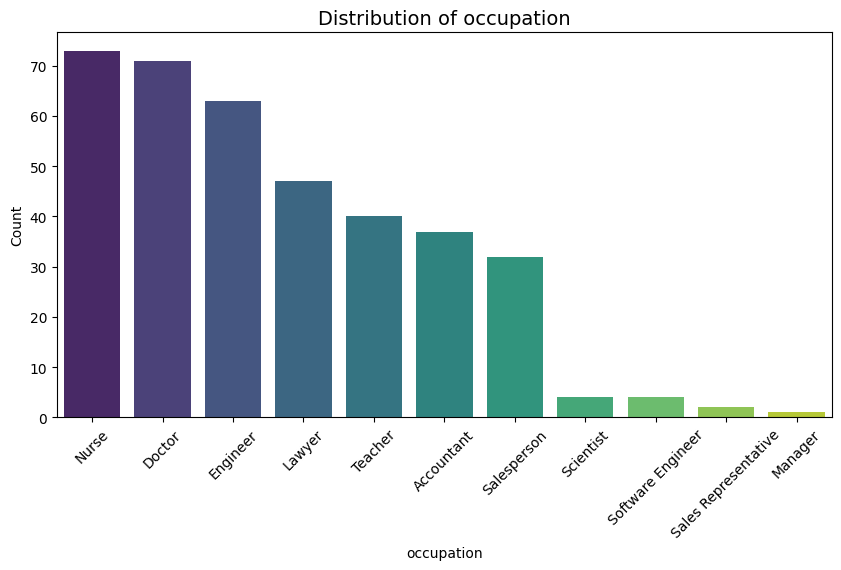

/tmp/ipython-input-2789756838.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var_counts.index, y=var_counts.values, palette='viridis')


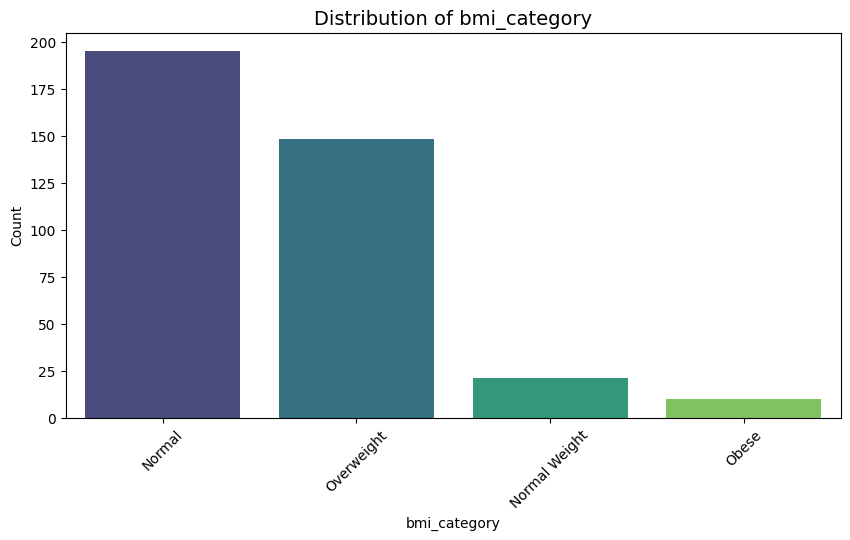

/tmp/ipython-input-2789756838.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var_counts.index, y=var_counts.values, palette='viridis')


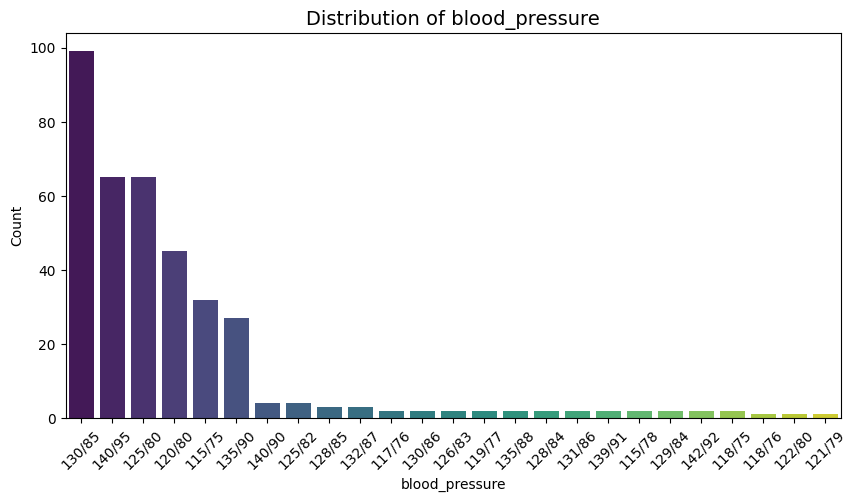

/tmp/ipython-input-2789756838.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=var_counts.index, y=var_counts.values, palette='viridis')


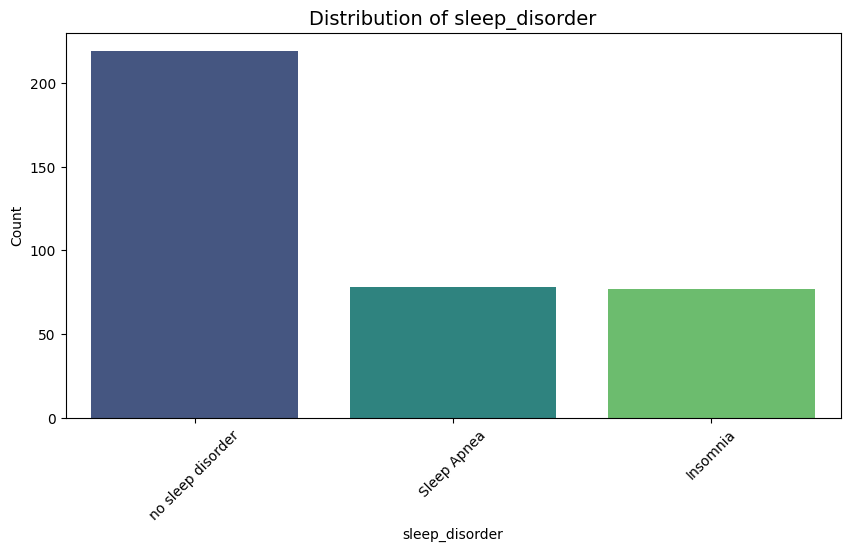

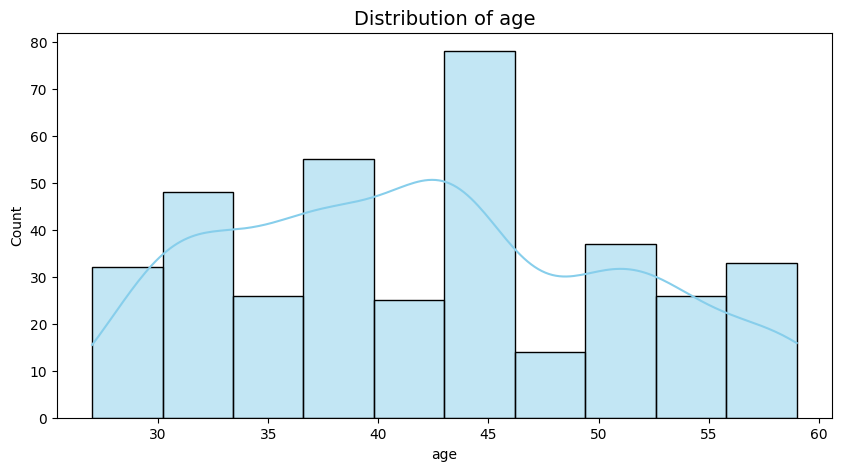

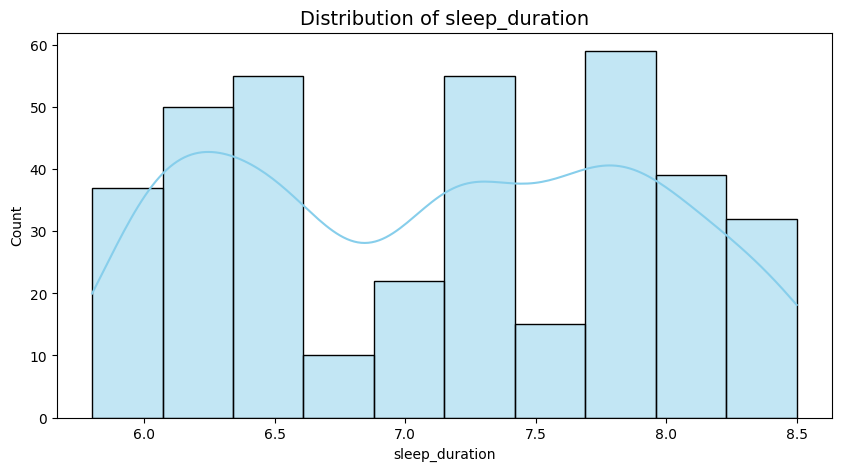

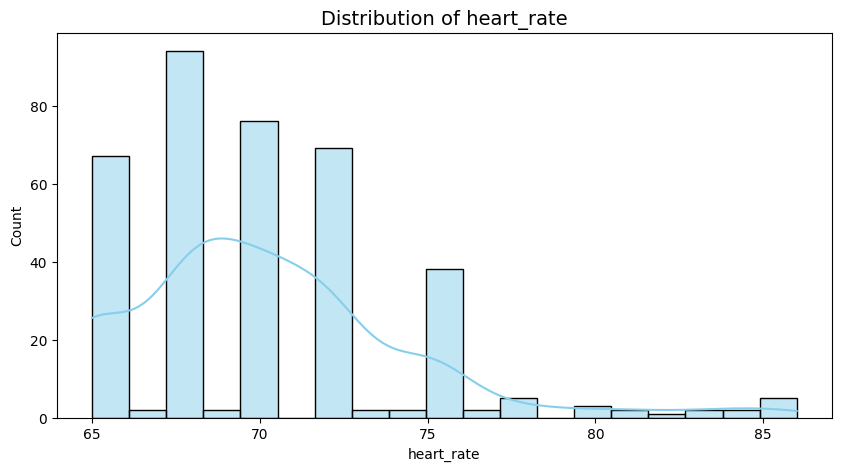

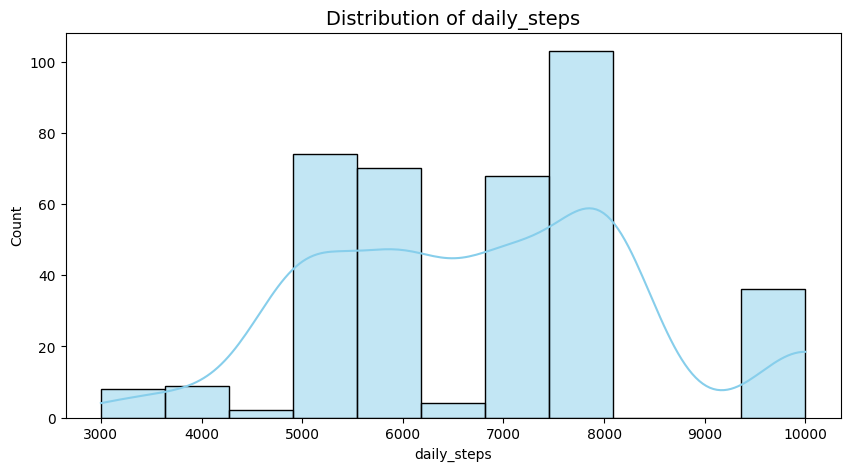

In [35]:
# Fix for Univariate Analysis of Categorical Vars
def bar_plot(variable):
    var_counts = df[variable].value_counts()
    plt.figure(figsize=(10, 5))
    sns.barplot(x=var_counts.index, y=var_counts.values, palette='viridis')
    plt.title(f'Distribution of {variable}', fontsize=14)
    plt.ylabel('Count')
    plt.xlabel(variable)
    plt.xticks(rotation=45)
    plt.show()

for c in categorical_vars:
    bar_plot(c)

# Add Univariate Analysis for Numerical Vars (To fully complete Review 4)
numerical_vars = ["age", "sleep_duration", "heart_rate", "daily_steps"]
for n in numerical_vars:
    plt.figure(figsize=(10, 5))
    sns.histplot(df[n], kde=True, color='skyblue')
    plt.title(f'Distribution of {n}', fontsize=14)
    plt.show()

In [36]:
# --- 1. Fix Inconsistent Categories ---
# In this dataset, 'Normal' and 'Normal Weight' are often duplicates. Let's merge them.
df['bmi_category'] = df['bmi_category'].replace('Normal Weight', 'Normal')
print("Updated BMI Categories:", df['bmi_category'].unique())

# --- 2. Feature Split: Blood Pressure ---
# Currently "126/83" (String). We need 126 and 83 (Integers).
df[['systolic_bp', 'diastolic_bp']] = df['blood_pressure'].str.split('/', expand=True).astype(int)

# --- 3. Feature Creation: Pulse Pressure ---
# Pulse pressure is the difference between Systolic and Diastolic (an indicator of heart health)
df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']

# Check the new columns
df[['blood_pressure', 'systolic_bp', 'diastolic_bp', 'pulse_pressure']].head()

Updated BMI Categories: ['Overweight' 'Normal' 'Obese']


,blood_pressure,systolic_bp,diastolic_bp,pulse_pressure
0,126/83,126,83,43
1,125/80,125,80,45
2,125/80,125,80,45
3,140/90,140,90,50
4,140/90,140,90,50


In [37]:
import plotly.express as px

# Create an interactive scatter plot
fig = px.scatter(
    df,
    x="age",
    y="sleep_duration",
    color="occupation",
    size="quality_of_sleep",  # The size of the bubble represents quality
    hover_data=["systolic_bp", "daily_steps", "stress_level"],
    title="Interactive: Sleep Duration by Age & Occupation (Size = Quality)",
    template="plotly_dark"
)

fig.show()

In [38]:
# --- Review 5: Feature Engineering ---

# 1. Fix inconsistencies in BMI (Medical Standard)
df['bmi_category'] = df['bmi_category'].replace('Normal Weight', 'Normal')

# 2. Advanced Feature: Split Blood Pressure into Systolic/Diastolic
# This allows us to treat BP as a number, not a string.
df[['systolic_bp', 'diastolic_bp']] = df['blood_pressure'].str.split('/', expand=True).astype(int)

# 3. Advanced Feature: Pulse Pressure
# (Systolic - Diastolic) is a key indicator of cardiovascular health
df['pulse_pressure'] = df['systolic_bp'] - df['diastolic_bp']

print("Feature Engineering Complete. New columns added.")
df[['blood_pressure', 'systolic_bp', 'diastolic_bp', 'pulse_pressure']].head()

Feature Engineering Complete. New columns added.


,blood_pressure,systolic_bp,diastolic_bp,pulse_pressure
0,126/83,126,83,43
1,125/80,125,80,45
2,125/80,125,80,45
3,140/90,140,90,50
4,140/90,140,90,50


--- 1. Statistical Hypothesis Test ---
T-statistic: 27.54
P-value: 8.51e-92
CONCLUSION: The difference is STATISTICALLY SIGNIFICANT. We reject the null hypothesis.
--------------------------------------------------

--- 2. Machine Learning: Feature Importance ---


/tmp/ipython-input-1888279380.py:61: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




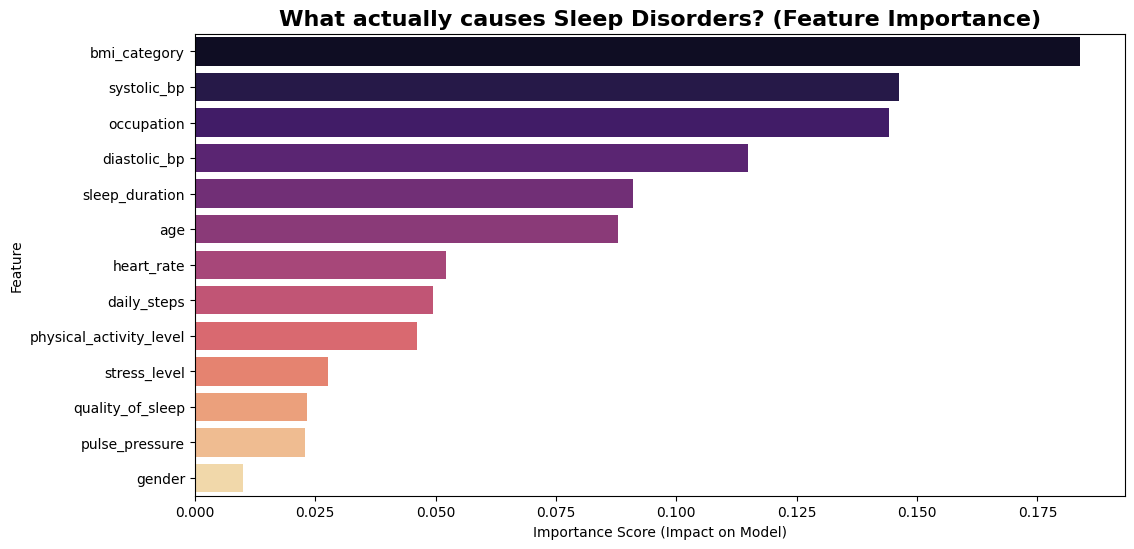

In [41]:
from scipy.stats import ttest_ind
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# ==========================================
# 1. STATISTICAL HYPOTHESIS TESTING (T-Test)
# ==========================================
print("--- 1. Statistical Hypothesis Test ---")

# Hypothesis: People with High Stress (>5) have statistically different Sleep Quality than Low Stress (<=5)
high_stress = df[df['stress_level'] > 5]['quality_of_sleep']
low_stress = df[df['stress_level'] <= 5]['quality_of_sleep']

# Run T-Test
t_stat, p_val = ttest_ind(low_stress, high_stress)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_val:.2e}") # Scientific notation

if p_val < 0.05:
    print("CONCLUSION: The difference is STATISTICALLY SIGNIFICANT. We reject the null hypothesis.")
else:
    print("CONCLUSION: No significant difference found.")

print("-" * 50)

# ==========================================
# 2. ML FEATURE IMPORTANCE (Random Forest)
# ==========================================
print("\n--- 2. Machine Learning: Feature Importance ---")

# Prepare data for ML
df_ml = df.copy()

# Encode categorical variables (Turn text into numbers for the AI)
le = LabelEncoder()
cat_cols = ['gender', 'occupation', 'bmi_category', 'sleep_disorder']
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Define Target (y) and Features (X)
X = df_ml.drop(['person_id', 'sleep_disorder', 'blood_pressure'], axis=1) # Drop ID and original BP string
y = df_ml['sleep_disorder']

# Train a Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X, y)

# Get Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False)

# Plot Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='magma')
plt.title('What actually causes Sleep Disorders? (Feature Importance)', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score (Impact on Model)')
plt.show()